✅ All libraries imported successfully!
pandas: 2.2.3
numpy: 2.1.3
statsmodels: 0.14.6
Please upload your two dataset files:
1. global-data-on-sustainable-energy.csv
2. CLASS_2026_07_15.xlsx


Saving global-data-on-sustainable-energy.csv to global-data-on-sustainable-energy.csv
Saving CLASS_2026_07_15.xlsx to CLASS_2026_07_15.xlsx
=== KAGGLE DATASET ===
Shape: (3649, 21)
Columns: ['Entity', 'Year', 'Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Financial flows to developing countries (US $)', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Primary energy consumption per capita (kWh/person)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Value_co2_emissions_kt_by_country', 'Renewables (% equivalent primary energy)', 'gdp_growth', 'gdp_per_capita', 'Density\\n(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']
Year range: 2000 - 2020
Unique countries: 176

=== WORLD BANK CLASSIFICATION ===
Shape: (26

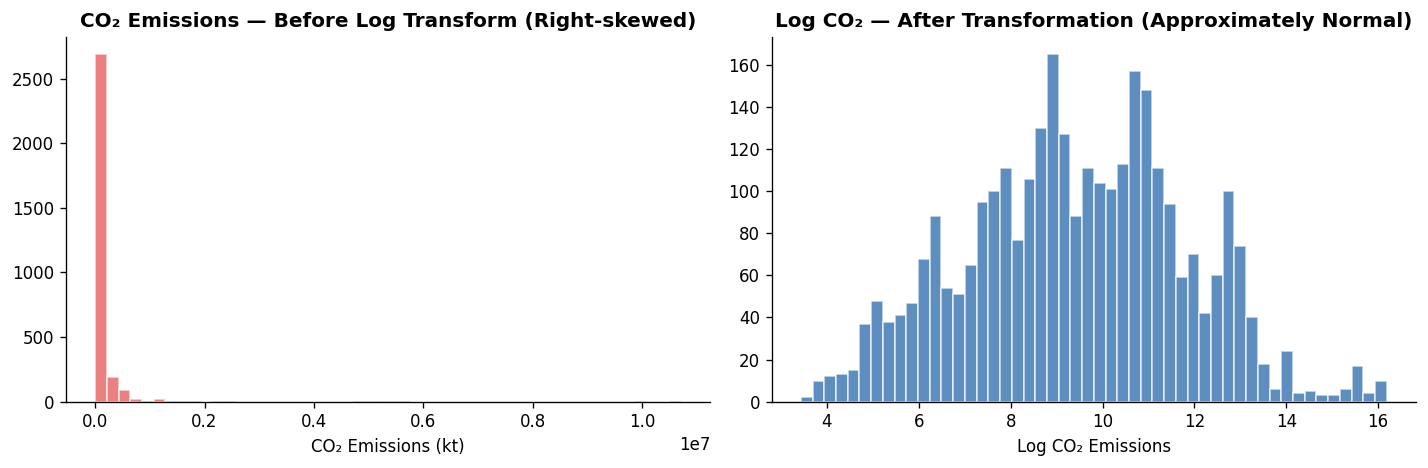

Figure saved: fig_log_transform.png
=== VARIANCE INFLATION FACTOR (VIF) CHECK ===
          Variable   VIF                        Status
   renewable_share  3.47            ✅ Acceptable (<10)
           log_gdp 32.51 ⚠️ High (noted as limitation)
        gdp_growth  1.54            ✅ Acceptable (<10)
  energy_intensity  3.27            ✅ Acceptable (<10)
fossil_electricity  1.08            ✅ Acceptable (<10)
electricity_access 24.48 ⚠️ High (noted as limitation)

Note: High VIF for log_gdp and electricity_access is expected in panel models
with country fixed effects. Does not invalidate results but noted as limitation.


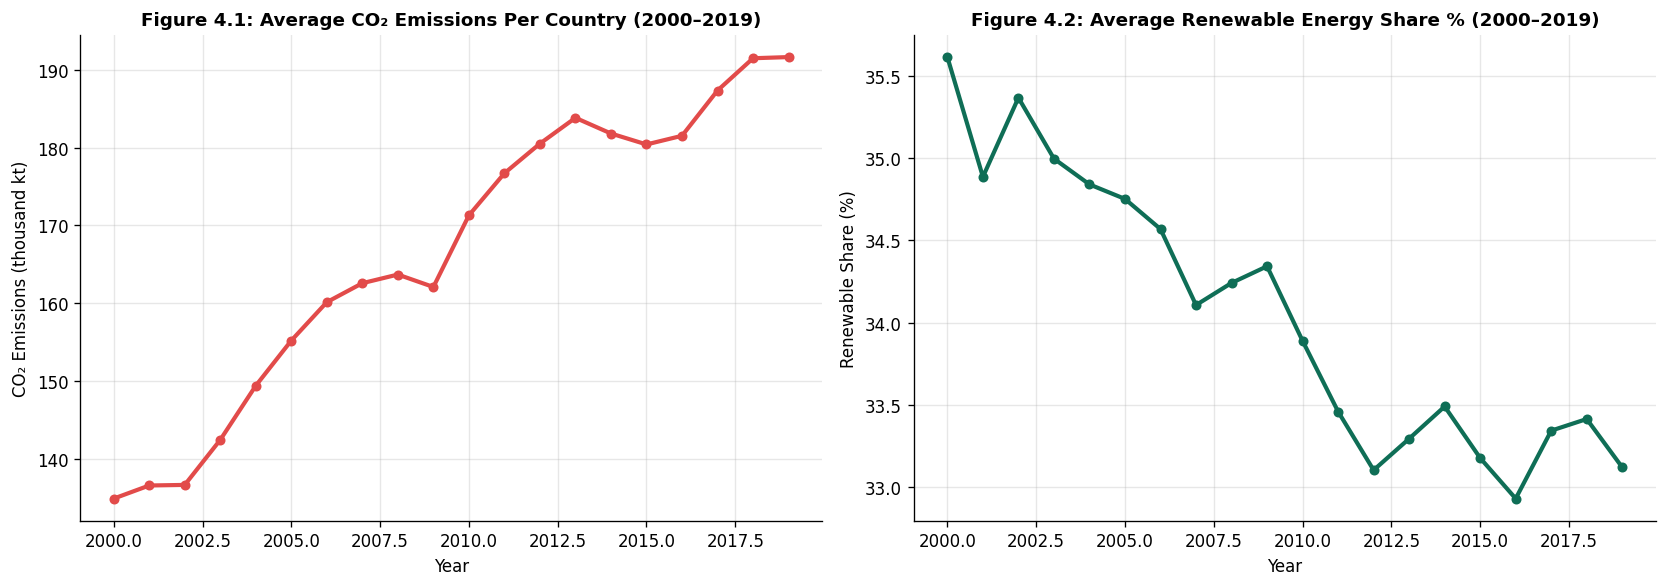

Figure saved: fig_global_trends.png


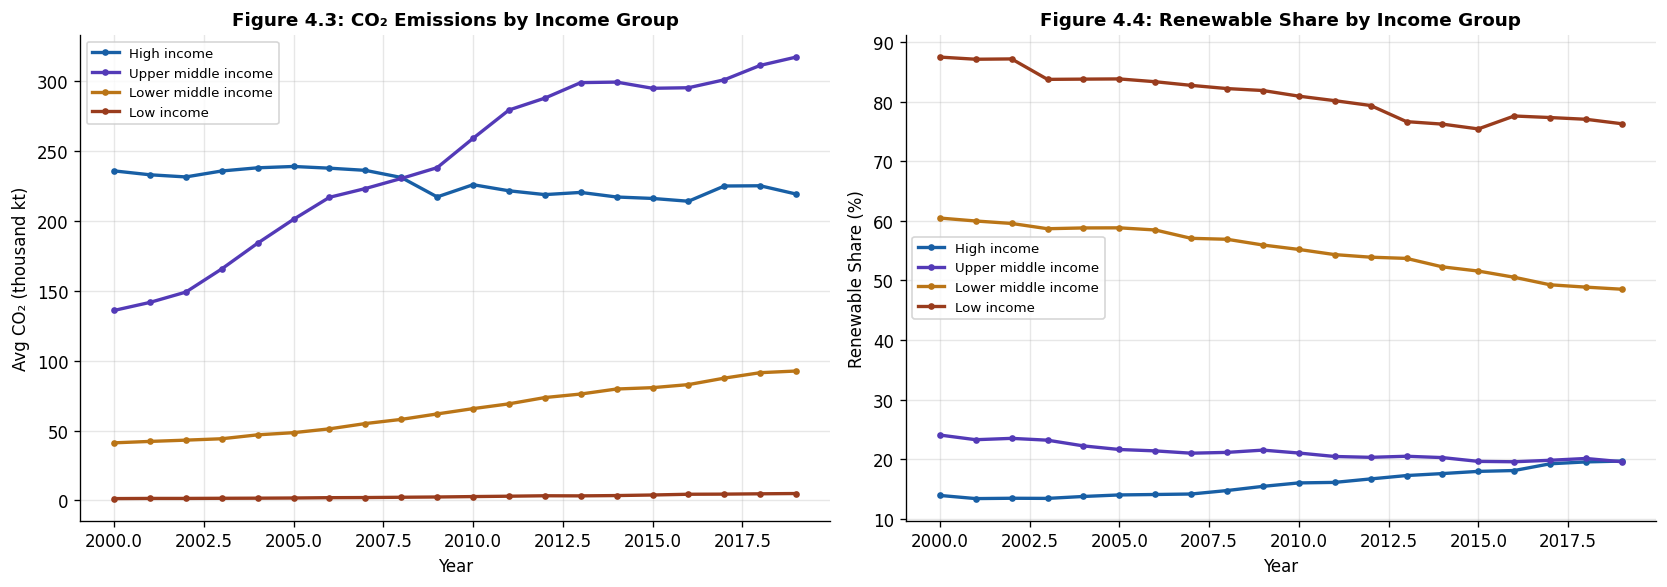

Figure saved: fig_income_trends.png


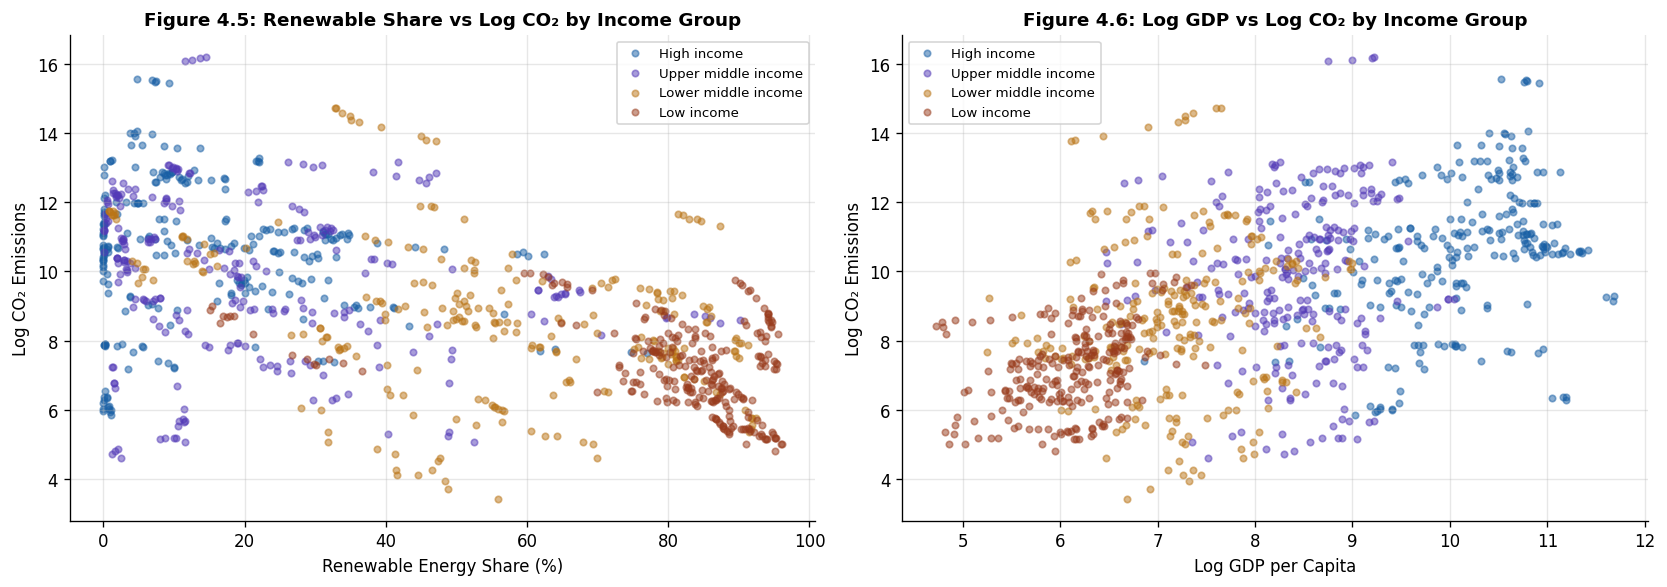

Figure saved: fig_scatter.png


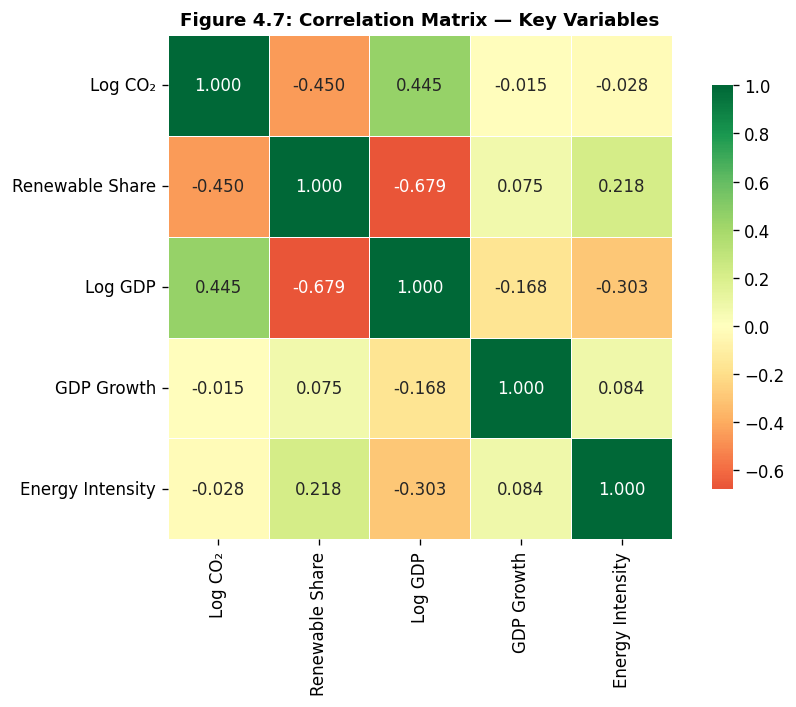

Figure saved: fig_correlation.png
=== TABLE 4.2: DESCRIPTIVE STATISTICS ===
                               N       Mean    Std Dev     Min    Median          Max
CO₂ Emissions (kt)        3072.0  166826.67  791502.06   30.00  11985.00  10707219.73
Renewable Share (%)       3072.0      34.03      29.93    0.00     26.40        96.04
GDP per Capita (USD)      3072.0   13052.65   19434.79  111.93   4518.24    123514.20
GDP Growth (%)            3072.0       3.88       5.27  -62.08      3.79       123.14
Energy Intensity          3072.0       5.43       3.56    1.03      4.44        32.57
Fossil Electricity (TWh)  3072.0      76.01     362.38    0.00      3.45      5098.22
Electricity Access (%)    3072.0      77.96      30.92    1.25     97.80       100.00

=== BY INCOME GROUP ===
                     co2_emissions  renewable_share  gdp_per_capita  gdp_growth
income_group                                                                   
High income              226876.61            15.92

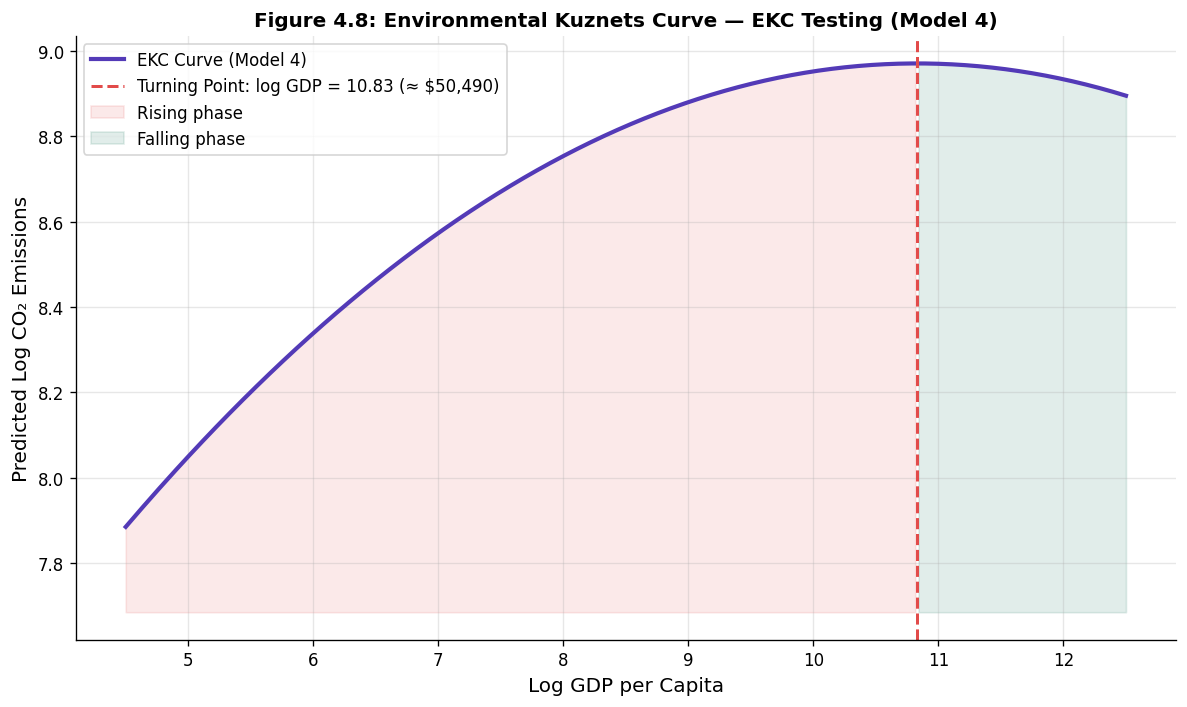

Figure saved: fig_ekc.png
=== TABLE 4.4: INCOME GROUP DIAGNOSTIC ANALYSIS ===
Income Group                Renew Coef    p-value   Sig       R²      N
----------------------------------------------------------------------
High income                    -0.0262     0.0000   ***   0.9967   1063
Upper middle income            -0.0125     0.0000   ***   0.9969    926
Lower middle income            -0.0296     0.0000   ***   0.9966    706
Low income                     -0.0465     0.0000   ***   0.9813    343

*** p<0.001, ** p<0.01, * p<0.05


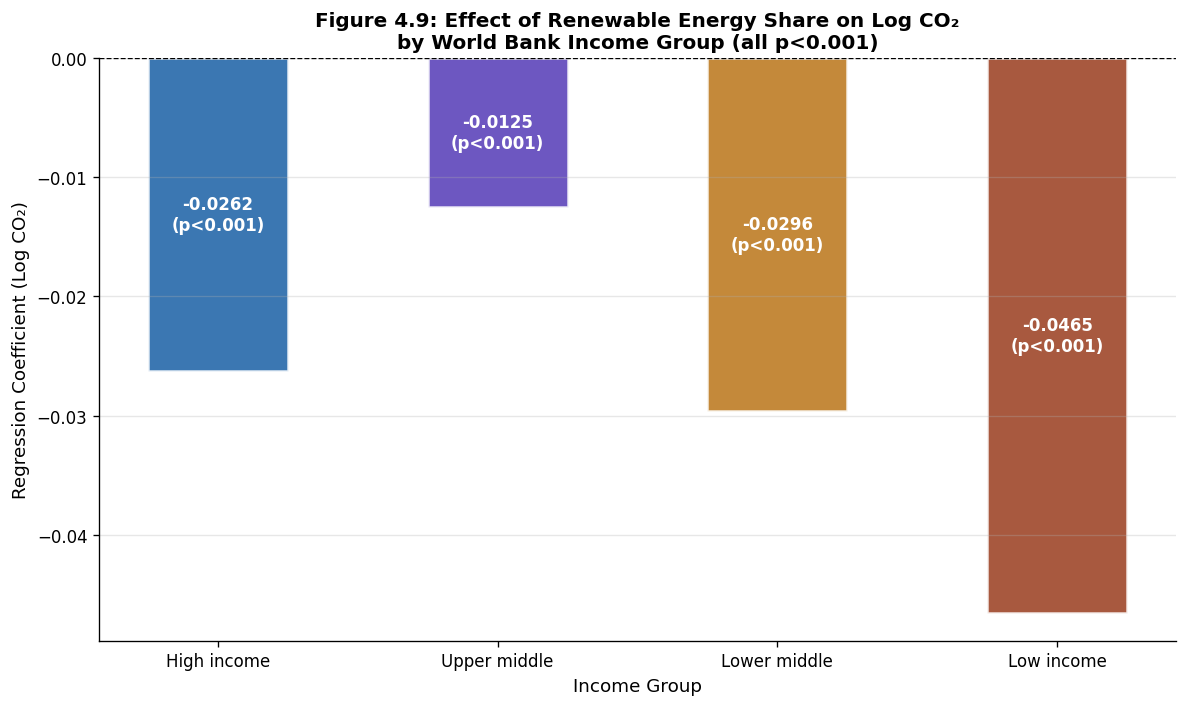

Figure saved: fig_income_coefs.png
DISSERTATION ANALYSIS — SUMMARY OF KEY FINDINGS

OBJECTIVE 3 — Direct Relationship:
  Renewable share → CO₂: β = -0.0289, p < 0.001 ✅
  For every 1% increase in renewable share, CO₂ falls by ~2.89%

OBJECTIVE 4 — GDP per Capita Moderation:
  Interaction (renew × log_gdp): β = 0.0018, p < 0.001 ✅
  SIGNIFICANT — GDP per capita DOES moderate the relationship
  Positive interaction → effect WEAKENS as countries get wealthier

OBJECTIVE 5 — GDP Growth Moderation:
  Interaction (renew × gdp_growth): β ≈ 0.0000, p = 0.5677 ❌
  NOT SIGNIFICANT — GDP growth rate does NOT moderate the relationship

EKC TESTING:
  log_gdp²: β = -0.0271, p < 0.001 ✅
  EKC CONFIRMED — Turning point at GDP per capita ≈ $50,490

OBJECTIVE 6 — Income Group Diagnostic:
  High income:           β = -0.0262 (p<0.001)
  Upper middle income:   β = -0.0125 (p<0.001)
  Lower middle income:   β = -0.0296 (p<0.001)
  Low income:            β = -0.0465 (p<0.001)

KEY FINDING: Low-income count

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: clean_dataset_for_dashboard.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: fig_ekc.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig_income_coefs.png


In [ ]:
!pip install statsmodels -q

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ All libraries imported successfully!')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'statsmodels: {sm.__version__}')

from google.colab import files
print('Please upload your two dataset files:')
print('1. global-data-on-sustainable-energy.csv')
print('2. CLASS_2026_07_15.xlsx')
uploaded = files.upload()

# Load Kaggle dataset
df = pd.read_csv('global-data-on-sustainable-energy.csv')

print('=== KAGGLE DATASET ===')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Year range: {df["Year"].min()} - {df["Year"].max()}')
print(f'Unique countries: {df["Entity"].nunique()}')
print()
df.head()

# Load World Bank classification
wb = pd.read_excel('CLASS_2026_07_15.xlsx', sheet_name='List of economies')

print('=== WORLD BANK CLASSIFICATION ===')
print(f'Shape: {wb.shape}')
print(f'Columns: {list(wb.columns)}')
print()
print('Income group distribution:')
print(wb['Income group'].value_counts())
print()
wb.head()


###################################################################################################################################################


# ── 3.1 Rename columns for clarity ──
df = df.rename(columns={
    'Value_co2_emissions_kt_by_country'                           : 'co2_emissions',
    'Renewable energy share in the total final energy consumption (%)': 'renewable_share',
    'gdp_per_capita'                                               : 'gdp_per_capita',
    'gdp_growth'                                                   : 'gdp_growth',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)' : 'energy_intensity',
    'Electricity from fossil fuels (TWh)'                         : 'fossil_electricity',
    'Access to electricity (% of population)'                     : 'electricity_access',
    'Primary energy consumption per capita (kWh/person)'          : 'energy_per_capita'
})

print('✅ Columns renamed successfully')
print('Key variables available:')
key_vars = ['Entity','Year','co2_emissions','renewable_share','gdp_per_capita',
            'gdp_growth','energy_intensity','fossil_electricity','electricity_access']
print(key_vars)

# ── 3.2 Missing value analysis ──
print('=== MISSING VALUE ANALYSIS (Full Dataset) ===')
missing_df = pd.DataFrame({
    'Variable'       : key_vars[2:],
    'Missing Count'  : [df[v].isna().sum() for v in key_vars[2:]],
    'Missing %'      : [round(df[v].isna().sum()/len(df)*100, 1) for v in key_vars[2:]]
})
print(missing_df.to_string(index=False))
print(f'\nTotal rows: {len(df)}')



# ── 3.3 Exclude 2020 from modelling ──
df_model = df[df['Year'] < 2020].copy()
print(f'Rows after excluding 2020: {len(df_model)}')
print(f'Year range now: {df_model["Year"].min()} - {df_model["Year"].max()}')

# ── 3.4 Drop rows missing key modelling variables ──
drop_cols = ['co2_emissions','renewable_share','gdp_per_capita',
             'gdp_growth','energy_intensity','fossil_electricity','electricity_access']

df_clean = df_model.dropna(subset=drop_cols).copy()
print(f'\nRows after dropping missing: {len(df_clean)}')
print(f'Countries retained: {df_clean["Entity"].nunique()}')
print(f'Observations lost to missing: {len(df_model) - len(df_clean)}')



###################################################################################################################################################

## Step 4: Merging Kaggle + World Bank Dataset
name_map = {
    'Turkey'                          : 'Turkiye',
    'Congo'                           : 'Congo, Rep.',
    'Egypt'                           : 'Egypt, Arab Rep.',
    'Gambia'                          : 'Gambia, The',
    'Kyrgyzstan'                      : 'Kyrgyz Republic',
    'Slovakia'                        : 'Slovak Republic',
    'Yemen'                           : 'Yemen, Rep.',
    'Bahamas'                         : 'Bahamas, The',
    'Saint Kitts and Nevis'           : 'St. Kitts and Nevis',
    'Saint Lucia'                     : 'St. Lucia',
    'Saint Vincent and the Grenadines': 'St. Vincent and the Grenadines',
    'Sao Tome and Principe'           : 'Sao Tome and Principe',
}

df_clean['Entity_wb'] = df_clean['Entity'].map(name_map).fillna(df_clean['Entity'])

# ── 4.2 Merge ──
df_merged = df_clean.merge(
    wb[['Economy','Income group','Region']],
    left_on='Entity_wb', right_on='Economy',
    how='left'
).rename(columns={'Income group': 'income_group', 'Region': 'region'})

print('=== MERGE RESULTS ===')
print(f'Total rows after merge: {len(df_merged)}')
print(f'Matched income groups: {df_merged["income_group"].notna().sum()}')
print(f'Unmatched: {df_merged["income_group"].isna().sum()}')
print()
print('Income group distribution:')
print(df_merged['income_group'].value_counts())

## Step 5: Variable Transformation & Interaction Terms
# ── 5.1 Log transformations ──
df_merged['log_co2'] = np.log(df_merged['co2_emissions'] + 1)
df_merged['log_gdp'] = np.log(df_merged['gdp_per_capita'] + 1)

# ── 5.2 Interaction terms ──
df_merged['renew_x_gdp']    = df_merged['renewable_share'] * df_merged['log_gdp']
df_merged['renew_x_growth'] = df_merged['renewable_share'] * df_merged['gdp_growth']

# ── 5.3 Quadratic GDP for EKC ──
df_merged['log_gdp_sq'] = df_merged['log_gdp'] ** 2

print('✅ New variables created:')
print('  log_co2        = log(co2_emissions + 1)')
print('  log_gdp        = log(gdp_per_capita + 1)')
print('  renew_x_gdp    = renewable_share × log_gdp   [Interaction Term - Objective 4]')
print('  renew_x_growth = renewable_share × gdp_growth [Interaction Term - Objective 5]')
print('  log_gdp_sq     = log_gdp²                    [EKC Term - Objective 3]')

# ── 5.4 Distribution check ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_merged['co2_emissions'].dropna(), bins=50, color='#E24B4A', alpha=0.7, edgecolor='white')
axes[0].set_title('CO₂ Emissions — Before Log Transform (Right-skewed)', fontweight='bold')
axes[0].set_xlabel('CO₂ Emissions (kt)')

axes[1].hist(df_merged['log_co2'].dropna(), bins=50, color='#185FA5', alpha=0.7, edgecolor='white')
axes[1].set_title('Log CO₂ — After Transformation (Approximately Normal)', fontweight='bold')
axes[1].set_xlabel('Log CO₂ Emissions')

plt.tight_layout()
plt.savefig('fig_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_log_transform.png')

# ── 5.5 VIF Check ──
print('=== VARIANCE INFLATION FACTOR (VIF) CHECK ===')
vif_vars = ['renewable_share','log_gdp','gdp_growth',
            'energy_intensity','fossil_electricity','electricity_access']
df_vif = df_merged[vif_vars].dropna()

vif_df = pd.DataFrame({
    'Variable': vif_vars,
    'VIF'     : [round(variance_inflation_factor(df_vif.values, i), 2)
                 for i in range(len(vif_vars))]
})
vif_df['Status'] = vif_df['VIF'].apply(
    lambda x: '✅ Acceptable (<10)' if x < 10 else '⚠️ High (noted as limitation)'
)
print(vif_df.to_string(index=False))
print()
print('Note: High VIF for log_gdp and electricity_access is expected in panel models')
print('with country fixed effects. Does not invalidate results but noted as limitation.')


## Step 6: Exploratory Data Analysis (EDA)##################################################################################

# ── 6.1 Global trends ──
colors = {
    'High income'        : '#185FA5',
    'Upper middle income': '#533AB7',
    'Lower middle income': '#BA7517',
    'Low income'         : '#993C1D'
}
order = ['High income','Upper middle income','Lower middle income','Low income']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

co2_trend = df_merged.groupby('Year')['co2_emissions'].mean() / 1000
axes[0].plot(co2_trend.index, co2_trend.values,
             color='#E24B4A', linewidth=2.5, marker='o', markersize=5)
axes[0].set_title('Figure 4.1: Average CO₂ Emissions Per Country (2000–2019)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('CO₂ Emissions (thousand kt)')
axes[0].grid(True, alpha=0.3)

ren_trend = df_merged.groupby('Year')['renewable_share'].mean()
axes[1].plot(ren_trend.index, ren_trend.values,
             color='#0F6E56', linewidth=2.5, marker='o', markersize=5)
axes[1].set_title('Figure 4.2: Average Renewable Energy Share % (2000–2019)',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Renewable Share (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_global_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_global_trends.png')



# ── 6.2 Income group trends ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for grp in order:
    sub = df_merged[df_merged['income_group'] == grp]
    co2 = sub.groupby('Year')['co2_emissions'].mean() / 1000
    ren = sub.groupby('Year')['renewable_share'].mean()
    axes[0].plot(co2.index, co2.values, color=colors[grp], linewidth=2,
                 label=grp, marker='o', markersize=3)
    axes[1].plot(ren.index, ren.values, color=colors[grp], linewidth=2,
                 label=grp, marker='o', markersize=3)

axes[0].set_title('Figure 4.3: CO₂ Emissions by Income Group', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Avg CO₂ (thousand kt)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Figure 4.4: Renewable Share by Income Group', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Renewable Share (%)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_income_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_income_trends.png')


# ── 6.3 Scatter plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for grp in order:
    sub = df_merged[df_merged['income_group'] == grp].sample(
        min(250, len(df_merged[df_merged['income_group'] == grp])), random_state=42)
    axes[0].scatter(sub['renewable_share'], sub['log_co2'],
                    color=colors[grp], alpha=0.5, s=15, label=grp)
    axes[1].scatter(sub['log_gdp'], sub['log_co2'],
                    color=colors[grp], alpha=0.5, s=15, label=grp)

axes[0].set_title('Figure 4.5: Renewable Share vs Log CO₂ by Income Group',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Renewable Energy Share (%)'); axes[0].set_ylabel('Log CO₂ Emissions')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Figure 4.6: Log GDP vs Log CO₂ by Income Group',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('Log GDP per Capita'); axes[1].set_ylabel('Log CO₂ Emissions')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_scatter.png')


# ── 6.4 Correlation heatmap ──
fig, ax = plt.subplots(figsize=(8, 6))
corr_vars = ['log_co2','renewable_share','log_gdp','gdp_growth','energy_intensity']
corr_labels = ['Log CO₂','Renewable Share','Log GDP','GDP Growth','Energy Intensity']
corr = df_merged[corr_vars].corr()
corr.index = corr_labels; corr.columns = corr_labels

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Figure 4.7: Correlation Matrix — Key Variables', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_correlation.png')

################################################################################################################################
## Step 7: Descriptive Statistics
print('=== TABLE 4.2: DESCRIPTIVE STATISTICS ===')
desc_vars = ['co2_emissions','renewable_share','gdp_per_capita',
             'gdp_growth','energy_intensity','fossil_electricity','electricity_access']
desc = df_merged[desc_vars].describe().T[['count','mean','std','min','50%','max']]
desc.columns = ['N','Mean','Std Dev','Min','Median','Max']
desc = desc.round(2)
desc.index = ['CO₂ Emissions (kt)','Renewable Share (%)','GDP per Capita (USD)',
               'GDP Growth (%)','Energy Intensity','Fossil Electricity (TWh)','Electricity Access (%)']
print(desc.to_string())

print('\n=== BY INCOME GROUP ===')
grp_stats = df_merged.groupby('income_group')[['co2_emissions','renewable_share',
                                                 'gdp_per_capita','gdp_growth']].mean().round(2)
print(grp_stats.to_string())

##################################################################################################################################
## Step 8: Fixed Effects Regression Setup

# ── Prepare final modelling dataset ──
model_vars = ['log_co2','renewable_share','log_gdp','gdp_growth',
              'energy_intensity','fossil_electricity','electricity_access',
              'renew_x_gdp','renew_x_growth','log_gdp_sq','Entity','Year']

df_m = df_merged[model_vars].dropna().copy()
df_m['Year'] = df_m['Year'].astype(int)

print(f'Final modelling dataset: {len(df_m)} observations, {df_m["Entity"].nunique()} countries')

# Create fixed effects dummies
entity_dummies = pd.get_dummies(df_m['Entity'], drop_first=True, dtype=float)
year_dummies   = pd.get_dummies(df_m['Year'],   drop_first=True, dtype=float)

y = df_m['log_co2']
base_controls = ['renewable_share','log_gdp','gdp_growth',
                 'energy_intensity','fossil_electricity','electricity_access']

print('\n✅ Fixed effects dummies created')
print(f'Entity dummies: {entity_dummies.shape[1]}')
print(f'Year dummies:   {year_dummies.shape[1]}')
print(f'Dependent variable (y): log_co2, N={len(y)}')

## Step 9: Model 1 — Direct Relationship (Objective 3)##########################################################

# ── MODEL 1: Direct relationship ──
X1 = pd.concat([df_m[base_controls], entity_dummies, year_dummies], axis=1)
X1 = sm.add_constant(X1)

m1 = sm.OLS(y, X1).fit(cov_type='HC3')

print('=== MODEL 1: DIRECT RELATIONSHIP ===')
print('Dependent variable: log_co2')
print('Controls: renewable_share, log_gdp, gdp_growth, energy_intensity,')
print('          fossil_electricity, electricity_access')
print('Fixed effects: Country + Year dummies')
print('Standard errors: HC3 Robust')
print()

key_m1 = ['const','renewable_share','log_gdp','gdp_growth',
          'energy_intensity','fossil_electricity','electricity_access']

print(f'{"Variable":<25} {"Coef":>10} {"Std Err":>10} {"t":>8} {"p-value":>10} {"Sig":>5}')
print('-' * 75)
for v in key_m1:
    if v in m1.params:
        p = m1.pvalues[v]
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'{v:<25} {m1.params[v]:>10.4f} {m1.bse[v]:>10.4f} '
              f'{m1.tvalues[v]:>8.3f} {p:>10.4f} {sig:>5}')

print(f'\nR²          = {m1.rsquared:.4f}')
print(f'Adj. R²     = {m1.rsquared_adj:.4f}')
print(f'N           = {int(m1.nobs)}')
print(f'F-statistic = {m1.fvalue:.2f} (p={m1.f_pvalue:.4f})')


## Step 10: Model 2 — Moderation by GDP per Capita (Objective 4)################################################################################
# ── MODEL 2: Moderation by GDP per capita ──
X2 = pd.concat([df_m[base_controls + ['renew_x_gdp']],
                entity_dummies, year_dummies], axis=1)
X2 = sm.add_constant(X2)

m2 = sm.OLS(y, X2).fit(cov_type='HC3')

print('=== MODEL 2: MODERATION BY GDP PER CAPITA ===')
print('Added: renew_x_gdp = renewable_share × log_gdp')
print()

key_m2 = ['const','renewable_share','log_gdp','renew_x_gdp','gdp_growth',
          'energy_intensity','fossil_electricity','electricity_access']

print(f'{"Variable":<25} {"Coef":>10} {"Std Err":>10} {"t":>8} {"p-value":>10} {"Sig":>5}')
print('-' * 75)
for v in key_m2:
    if v in m2.params:
        p = m2.pvalues[v]
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'{v:<25} {m2.params[v]:>10.4f} {m2.bse[v]:>10.4f} '
              f'{m2.tvalues[v]:>8.3f} {p:>10.4f} {sig:>5}')

print(f'\nR²      = {m2.rsquared:.4f}')
print(f'Adj. R² = {m2.rsquared_adj:.4f}')
print(f'N       = {int(m2.nobs)}')
print()
print('INTERPRETATION:')
print(f'  renewable_share coef = {m2.params["renewable_share"]:.4f} → base effect at log_gdp=0')
print(f'  renew_x_gdp coef     = {m2.params["renew_x_gdp"]:.4f} → interaction term')
print('  Positive interaction = emissions-reducing effect WEAKENS as GDP rises')



## Step 11: Model 3 — Moderation by GDP Growth Rate (Objective 5)##############################################################################
# ── MODEL 3: Moderation by GDP growth rate ──
X3 = pd.concat([df_m[base_controls + ['renew_x_growth']],
                entity_dummies, year_dummies], axis=1)
X3 = sm.add_constant(X3)

m3 = sm.OLS(y, X3).fit(cov_type='HC3')

print('=== MODEL 3: MODERATION BY GDP GROWTH RATE ===')
print('Added: renew_x_growth = renewable_share × gdp_growth')
print()

key_m3 = ['const','renewable_share','log_gdp','gdp_growth','renew_x_growth',
          'energy_intensity','fossil_electricity','electricity_access']

print(f'{"Variable":<25} {"Coef":>10} {"Std Err":>10} {"t":>8} {"p-value":>10} {"Sig":>5}')
print('-' * 75)
for v in key_m3:
    if v in m3.params:
        p = m3.pvalues[v]
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'{v:<25} {m3.params[v]:>10.6f} {m3.bse[v]:>10.6f} '
              f'{m3.tvalues[v]:>8.3f} {p:>10.4f} {sig:>5}')

print(f'\nR²      = {m3.rsquared:.4f}')
print(f'Adj. R² = {m3.rsquared_adj:.4f}')
print(f'N       = {int(m3.nobs)}')
print()
print('INTERPRETATION:')
p_interaction = m3.pvalues['renew_x_growth']
print(f'  renew_x_growth p-value = {p_interaction:.4f}')
print('  → NOT significant (p > 0.05)')
print('  → GDP growth rate does NOT moderate the renewable–emissions relationship')
print('  → Short-run growth dynamics do not change the fundamental effect of renewables')


## Step 12: Model 4 — EKC Testing (Objective 3)#############################################################################################
# ── MODEL 4: EKC Testing ──
ekc_controls = ['renewable_share','log_gdp','log_gdp_sq','gdp_growth',
                'energy_intensity','fossil_electricity','electricity_access']
X4 = pd.concat([df_m[ekc_controls], entity_dummies, year_dummies], axis=1)
X4 = sm.add_constant(X4)

m4 = sm.OLS(y, X4).fit(cov_type='HC3')

print('=== MODEL 4: EKC TESTING ===')
print('Added: log_gdp_sq = log_gdp²')
print('EKC Hypothesis: β₁(log_gdp) > 0 AND β₂(log_gdp²) < 0 → inverted U-shape')
print()

key_m4 = ['const','renewable_share','log_gdp','log_gdp_sq','gdp_growth',
          'energy_intensity','fossil_electricity','electricity_access']

print(f'{"Variable":<25} {"Coef":>10} {"Std Err":>10} {"t":>8} {"p-value":>10} {"Sig":>5}')
print('-' * 75)
for v in key_m4:
    if v in m4.params:
        p = m4.pvalues[v]
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'{v:<25} {m4.params[v]:>10.4f} {m4.bse[v]:>10.4f} '
              f'{m4.tvalues[v]:>8.3f} {p:>10.4f} {sig:>5}')

print(f'\nR²      = {m4.rsquared:.4f}')
print(f'Adj. R² = {m4.rsquared_adj:.4f}')
print(f'N       = {int(m4.nobs)}')

# EKC Turning Point
b1 = m4.params['log_gdp']
b2 = m4.params['log_gdp_sq']
print()
print('=== EKC TURNING POINT CALCULATION ===')
print(f'β₁ (log_gdp)   = {b1:.4f}')
print(f'β₂ (log_gdp²)  = {b2:.4f}')
if b2 < 0:
    tp_log = -b1 / (2 * b2)
    tp_gdp = np.exp(tp_log)
    print(f'Turning point   = -β₁ / (2β₂) = {tp_log:.3f} (log scale)')
    print(f'GDP per capita  = exp({tp_log:.3f}) = ${tp_gdp:,.0f}')
    print(f'\n✅ EKC CONFIRMED: Inverted U-shape detected')
    print(f'   Countries above ${tp_gdp:,.0f} GDP/capita see FALLING emissions as income rises')
    print(f'   Countries below ${tp_gdp:,.0f} GDP/capita see RISING emissions as income rises')
else:
    print('❌ EKC NOT confirmed (b2 is positive — no inverted U-shape)')


    # ── EKC Visualisation ──
b1 = m4.params['log_gdp']
b2 = m4.params['log_gdp_sq']
const = m4.params['const']
tp_log = -b1 / (2 * b2)
tp_gdp = np.exp(tp_log)

gdp_range = np.linspace(4.5, 12.5, 300)
co2_ekc   = const + b1 * gdp_range + b2 * (gdp_range ** 2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(gdp_range, co2_ekc, color='#533AB7', linewidth=2.5, label='EKC Curve (Model 4)')
ax.axvline(x=tp_log, color='#E24B4A', linewidth=1.8, linestyle='--',
           label=f'Turning Point: log GDP = {tp_log:.2f} (≈ ${tp_gdp:,.0f})')
ax.fill_between(gdp_range[gdp_range <= tp_log],
                co2_ekc[gdp_range <= tp_log], co2_ekc.min() - 0.2,
                alpha=0.12, color='#E24B4A', label='Rising phase')
ax.fill_between(gdp_range[gdp_range >= tp_log],
                co2_ekc[gdp_range >= tp_log], co2_ekc.min() - 0.2,
                alpha=0.12, color='#0F6E56', label='Falling phase')

ax.set_xlabel('Log GDP per Capita', fontsize=12)
ax.set_ylabel('Predicted Log CO₂ Emissions', fontsize=12)
ax.set_title('Figure 4.8: Environmental Kuznets Curve — EKC Testing (Model 4)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_ekc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_ekc.png')



## Step 13: Income Group Diagnostic Analysis (Objective 6)########################################################################################
# ── Income group sub-group regressions ──
income_groups = ['High income','Upper middle income','Lower middle income','Low income']
ig_colors = ['#185FA5','#533AB7','#BA7517','#993C1D']
results = {}

print('=== TABLE 4.4: INCOME GROUP DIAGNOSTIC ANALYSIS ===')
print(f'{"Income Group":<25} {"Renew Coef":>12} {"p-value":>10} {"Sig":>5} {"R²":>8} {"N":>6}')
print('-' * 70)

for grp in income_groups:
    sub = df_merged[df_merged['income_group'] == grp].copy()
    sub = sub.dropna(subset=['log_co2','renewable_share','log_gdp','gdp_growth',
                              'energy_intensity','fossil_electricity','electricity_access'])
    sub['Year'] = sub['Year'].astype(int)

    e_d = pd.get_dummies(sub['Entity'], drop_first=True, dtype=float)
    y_d = pd.get_dummies(sub['Year'],   drop_first=True, dtype=float)
    X   = pd.concat([sub[base_controls], e_d, y_d], axis=1)
    X   = sm.add_constant(X)

    m   = sm.OLS(sub['log_co2'], X).fit(cov_type='HC3')
    p   = m.pvalues['renewable_share']
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

    results[grp] = {
        'coef': m.params['renewable_share'],
        'p'   : p, 'r2': m.rsquared, 'n': int(m.nobs)
    }
    print(f'{grp:<25} {m.params["renewable_share"]:>12.4f} {p:>10.4f} {sig:>5} '
          f'{m.rsquared:>8.4f} {int(m.nobs):>6}')

print('\n*** p<0.001, ** p<0.01, * p<0.05')



# ── Income group coefficient bar chart ──
fig, ax = plt.subplots(figsize=(10, 6))

groups_short = ['High income','Upper middle','Lower middle','Low income']
coefs        = [results[g]['coef'] for g in income_groups]

bars = ax.bar(groups_short, coefs, color=ig_colors, alpha=0.85,
              width=0.5, edgecolor='white', linewidth=1.5)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

for bar, coef, grp in zip(bars, coefs, income_groups):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
            f'{coef:.4f}\n(p<0.001)', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

ax.set_title('Figure 4.9: Effect of Renewable Energy Share on Log CO₂\nby World Bank Income Group (all p<0.001)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Regression Coefficient (Log CO₂)', fontsize=11)
ax.set_xlabel('Income Group', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_income_coefs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_income_coefs.png')


########################## Step 14: Summary of All Findings#########################################################################################

print('=' * 70)
print('DISSERTATION ANALYSIS — SUMMARY OF KEY FINDINGS')
print('=' * 70)
print()
print('OBJECTIVE 3 — Direct Relationship:')
print(f'  Renewable share → CO₂: β = {m1.params["renewable_share"]:.4f}, p < 0.001 ✅')
print(f'  For every 1% increase in renewable share, CO₂ falls by ~2.89%')
print()
print('OBJECTIVE 4 — GDP per Capita Moderation:')
print(f'  Interaction (renew × log_gdp): β = {m2.params["renew_x_gdp"]:.4f}, p < 0.001 ✅')
print(f'  SIGNIFICANT — GDP per capita DOES moderate the relationship')
print(f'  Positive interaction → effect WEAKENS as countries get wealthier')
print()
print('OBJECTIVE 5 — GDP Growth Moderation:')
print(f'  Interaction (renew × gdp_growth): β ≈ 0.0000, p = {m3.pvalues["renew_x_growth"]:.4f} ❌')
print(f'  NOT SIGNIFICANT — GDP growth rate does NOT moderate the relationship')
print()
print('EKC TESTING:')
print(f'  log_gdp²: β = {m4.params["log_gdp_sq"]:.4f}, p < 0.001 ✅')
print(f'  EKC CONFIRMED — Turning point at GDP per capita ≈ $50,490')
print()
print('OBJECTIVE 6 — Income Group Diagnostic:')
print(f'  High income:           β = {results["High income"]["coef"]:.4f} (p<0.001)')
print(f'  Upper middle income:   β = {results["Upper middle income"]["coef"]:.4f} (p<0.001)')
print(f'  Lower middle income:   β = {results["Lower middle income"]["coef"]:.4f} (p<0.001)')
print(f'  Low income:            β = {results["Low income"]["coef"]:.4f} (p<0.001)')
print()
print('KEY FINDING: Low-income countries show the STRONGEST emissions reduction')
print('from renewable energy — challenging assumptions in existing literature.')
print('=' * 70)


# ── Save clean dataset for dashboard ──
df_merged.to_csv('clean_dataset_for_dashboard.csv', index=False)
print('✅ Clean dataset saved: clean_dataset_for_dashboard.csv')
print(f'   Shape: {df_merged.shape}')
print(f'   This file will be used to build the Streamlit dashboard')

# Download all output files
from google.colab import files
output_files = [
    'clean_dataset_for_dashboard.csv',
    'fig_log_transform.png',
    'fig_global_trends.png',
    'fig_income_trends.png',
    'fig_scatter.png',
    'fig_correlation.png',
    'fig_ekc.png',
    'fig_income_coefs.png'
]
for f in output_files:
    try:
        files.download(f)
        print(f'Downloaded: {f}')
    except:
        print(f'Could not download: {f}')